Load Healthy Models

In [1]:
import torch
from pathlib import Path
import joblib
# prefix = Path("generate_plots.ipynb").resolve().parent

path_prefix ="synthetic_experiments_dif_hp/healthy/trained_models/unscaled/"
## create a function to load the model from the given string path
def load_model(model_path):

    model = torch.load(model_path)
    return model

models = {}
## loop through differen encoding folders to load the models per type
for enc_size in [2, 4, 8, 16]:
    for model_type in ["pca", "ae_basic", "ae_layered"]:
        if model_type == "pca":
            model_path = f"{path_prefix}{model_type}/enc_{enc_size}/model.joblib"
            model = joblib.load(model_path)
            print(f"Loaded {model_type} with encoding size {enc_size} from {model_path}")
        else:
            model_path = f"{path_prefix}{model_type}/enc_{enc_size}/model.pt"
            model = load_model(model_path)
            print(f"Loaded {model_type} with encoding size {enc_size} from {model_path}")
    models[enc_size] = {model_type: model for model_type in ["pca", "ae_basic", "ae_layered"]}


Loaded pca with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_2/model.joblib
Loaded ae_basic with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_2/model.pt
Loaded ae_layered with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_layered/enc_2/model.pt
Loaded pca with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_4/model.joblib
Loaded ae_basic with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_4/model.pt
Loaded ae_layered with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_layered/enc_4/model.pt
Loaded pca with encoding size 8 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_8/model.joblib
Loaded ae_basic with encoding size 8 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_8/mod

LOAD PCA HEALTHY MODEL

In [2]:
pca_healthy = {enc_size: models[enc_size]["pca"] for enc_size in models}
ae_basic_healthy = {enc_size: models[enc_size]["ae_basic"] for enc_size in models}
ae_layered_healthy = {enc_size: models[enc_size]["ae_layered"] for enc_size in models}
# print(pca_healthy)

LOAD TRAIN/VALIDATION VALUES FOR HEALTHY MODELS

In [3]:
import json
def load_history(model_history_path, is_pca=False):
    with open(model_history_path, 'r') as f:
        history_file = json.load(f)
    if is_pca:
        train_loss = history_file["train_mse"]
        val_loss = history_file["val_mse"]
        test_mse = history_file["test_mse"]
        return train_loss, val_loss, test_mse
    train_loss = history_file["train"]
    val_loss = history_file["val"]
    return train_loss, val_loss, None

In [4]:

## will hold the history for all models, with keys as (enc_size, model_type) and values as the history, which is a map in itself with keys train_mse, val_mse
history_map = {}
for enc_size in [2, 4, 8, 16]:
    for model_type in ["pca", "ae_basic", "ae_layered"]:
        if model_type == "pca":
            model_history_path = f"{path_prefix}{model_type}/enc_{enc_size}/results.json"
            history = load_history(model_history_path, is_pca=True)
            print(f"Loaded history for {model_type} with encoding size {enc_size} from {model_history_path}")
        else:
            model_history_path = f"{path_prefix}{model_type}/enc_{enc_size}/history.json"
            history = load_history(model_history_path)
            print(f"Loaded history for {model_type} with encoding size {enc_size} from {model_history_path}")

        history_map[(enc_size, model_type)] = {"train_curve_loss": history[0], "val_curve_loss": history[1]}

        ## if test mse is not None, add it to the history map
        if history[2] is not None:
            history_map[(enc_size, model_type)]["test_mse"] = history[2]

Loaded history for pca with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_2/results.json
Loaded history for ae_basic with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_2/history.json
Loaded history for ae_layered with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_layered/enc_2/history.json
Loaded history for pca with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_4/results.json
Loaded history for ae_basic with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_4/history.json
Loaded history for ae_layered with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_layered/enc_4/history.json
Loaded history for pca with encoding size 8 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_8/results.json
Loaded history for ae

CREATE TRAIN/VALIDATION LOSS CURVE GRAPH, CHOSEN ENC, 6 LINES, 2 PER MODEL TYPE


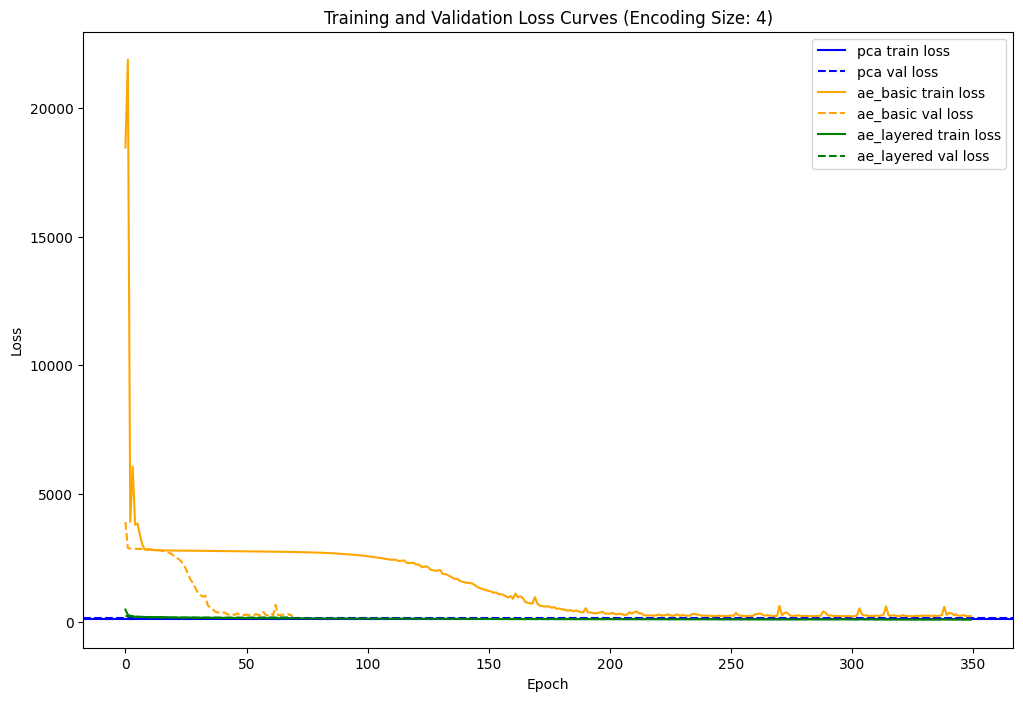

In [5]:
import matplotlib.pyplot as plt
import numpy as np
##color map for the different models
color_map = {"pca": "blue", "ae_basic": "orange", "ae_layered": "green"}
##plot train as solid, val as dashed
## plotting train val loss curves of the models for a certain encoding size
plt.figure(figsize=(12, 8))
enc = 4
for model_type in ["pca", "ae_basic", "ae_layered"]:
    history = history_map[(enc, model_type)]
    train_curve = history['train_curve_loss']
    eval_curve = history['val_curve_loss']
    if model_type == 'pca' and not isinstance(train_curve, list):
        plt.axhline(train_curve, label=f"{model_type} train loss", color=color_map[model_type])
        plt.axhline(eval_curve, label=f"{model_type} val loss", color=color_map[model_type], linestyle="--")
        continue
    plt.plot(train_curve, label=f"{model_type} train loss", color=color_map[model_type])
    plt.plot(eval_curve, label=f"{model_type} val loss", color=color_map[model_type], linestyle="--")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training and Validation Loss Curves (Encoding Size: {enc})")
plt.legend()
plt.show()
plt.close()

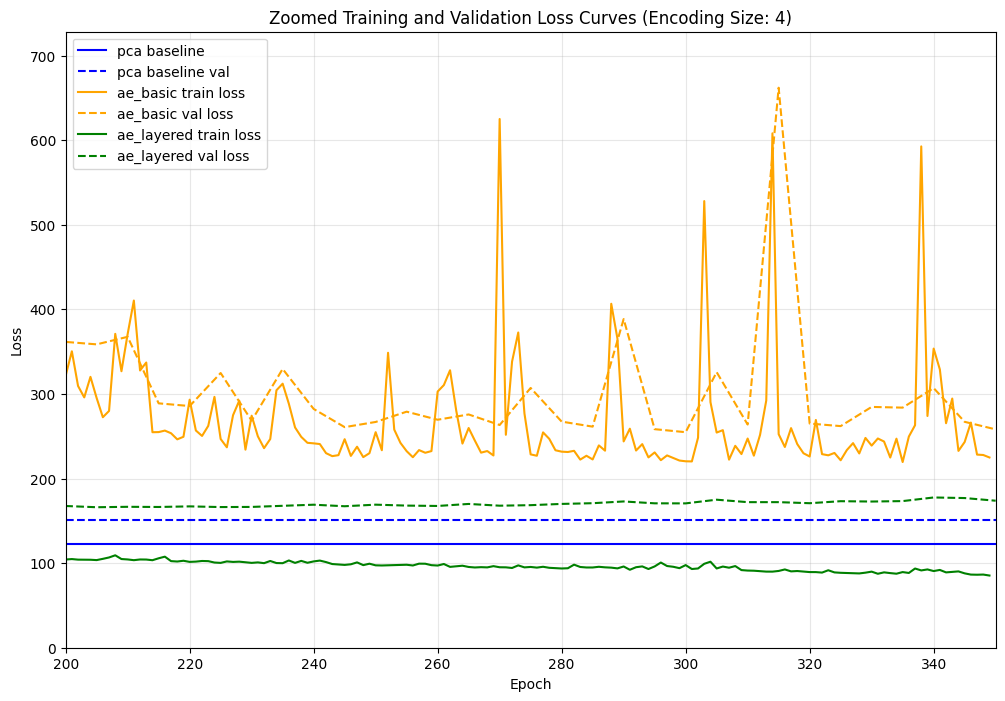

In [6]:
## Same code, but now with zoom on last 100 epochs, according to two best models
plt.figure(figsize=(12, 8))
enc = 4
start_x = 200
y_max = 0 # Track global max for the y-axis limit

for model_type in ["pca", "ae_basic", "ae_layered"]:
    history = history_map[(enc, model_type)]
    train_curve = history['train_curve_loss']
    eval_curve = history['val_curve_loss']
    
    
    if model_type == 'pca':
        pca_train = train_curve[0] if isinstance(train_curve, list) else train_curve
        pca_eval = eval_curve[0] if isinstance(eval_curve, list) else eval_curve
        plt.axhline(y=pca_train, label=f"{model_type} baseline", color=color_map[model_type])
        plt.axhline(y=pca_eval, label=f"{model_type} baseline val", color=color_map[model_type], linestyle="--")
        # Only update y_max if PCA is the highest value in the window
        y_max = max(y_max, pca_train * 1.1)
        continue # Skip the epoch logic below entirely for PCA
        
    
    plt.plot(train_curve, label=f"{model_type} train loss", color=color_map[model_type])
    
    epoch_jump = len(train_curve) // len(eval_curve) if len(eval_curve) > 0 else 1
    eval_epochs = np.arange(epoch_jump, len(train_curve) + 1, epoch_jump)
    eval_epochs = eval_epochs[:len(eval_curve)]
    plt.plot(eval_epochs, eval_curve, label=f"{model_type} val loss", color=color_map[model_type], linestyle="--")

    
    zoomed_train = train_curve[start_x:]
                            
    # Grab only the eval data in the zoomed window
    eval_start_idx = start_x // epoch_jump
    zoomed_eval = eval_curve[eval_start_idx:] if len(eval_curve) > 0 else [0]
                            
    max_train = max(zoomed_train) if zoomed_train else 0
    max_eval = max(zoomed_eval) if zoomed_eval else 0
    local_max = max(max_train, max_eval)
                            
    # Conditionally update the global y_max instead of overwriting it
    if local_max * 1.1 > y_max:
        y_max = local_max * 1.1

plt.xlim(start_x, len(train_curve))
plt.ylim(0, y_max)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Zoomed Training and Validation Loss Curves (Encoding Size: {enc})")
plt.legend()
plt.grid(True, alpha=0.3) 

plt.show()
plt.close()

In [7]:
import torch
from pathlib import Path
import joblib
# prefix = Path("generate_plots.ipynb").resolve().parent

path_prefix ="synthetic_experiments_dif_hp/healthy/trained_models/unscaled/"
## create a function to load the model from the given string path
def load_model(model_path):

    model = torch.load(model_path)
    return model

models = {}
## loop through differen encoding folders to load the models per type
for enc_size in [2, 4, 8, 16]:
    for model_type in ["pca", "ae_basic", "ae_layered"]:
        if model_type == "pca":
            model_path = f"{path_prefix}{model_type}/enc_{enc_size}/model.joblib"
            model = joblib.load(model_path)
            print(f"Loaded {model_type} with encoding size {enc_size} from {model_path}")
        else:
            model_path = f"{path_prefix}{model_type}/enc_{enc_size}/model.pt"
            model = load_model(model_path)
            print(f"Loaded {model_type} with encoding size {enc_size} from {model_path}")
    models[enc_size] = {model_type: model for model_type in ["pca", "ae_basic", "ae_layered"]}


Loaded pca with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_2/model.joblib
Loaded ae_basic with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_2/model.pt
Loaded ae_layered with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_layered/enc_2/model.pt
Loaded pca with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_4/model.joblib
Loaded ae_basic with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_4/model.pt
Loaded ae_layered with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_layered/enc_4/model.pt
Loaded pca with encoding size 8 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_8/model.joblib
Loaded ae_basic with encoding size 8 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_8/mod

BOXPLOTS FOR TEST MSE RESULTS

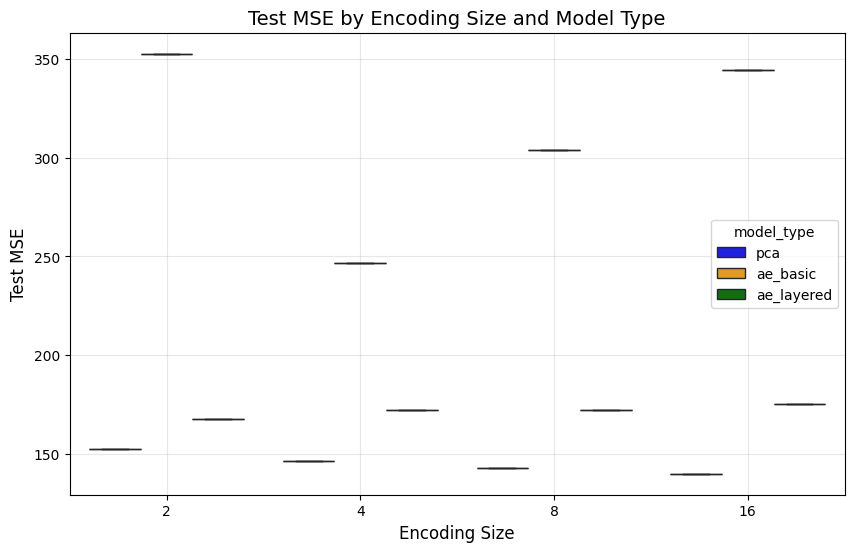

In [11]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path_prefix = "synthetic_experiments_dif_hp/healthy/trained_models/unscaled/"
color_map = {"pca": "blue", "ae_basic": "orange", "ae_layered": "green"}

# 1. Collect the data
data_records = []

for enc_size in [2, 4, 8, 16]:
    for model_type in ["pca", "ae_basic", "ae_layered"]:
        mse_value = None
        
        # Determine the correct file path based on model type
        if model_type == "pca":
            filepath = f"{path_prefix}{model_type}/enc_{enc_size}/results.json"
        else:
            filepath = f"{path_prefix}{model_type}/enc_{enc_size}/best_meta.json"
            
        # Read the file and extract test_mse
        try:
            with open(filepath, 'r') as f:
                file_content = json.load(f)
                
                # Check for test_mse key (adjust if your autoencoder key is slightly different!)
                if "test_mse" in file_content:
                    mse_value = file_content["test_mse"]
                else:
                    print(f"Warning: 'test_mse' not found in {filepath}")
                    
        except FileNotFoundError:
            print(f"Warning: File not found: {filepath}")
            
        # If we successfully found an MSE, add it to our records
        if mse_value is not None:
            # If you run multiple seeds/k-folds, mse_value might be a list. 
            # This handles both lists of MSEs and single float MSEs.
            if isinstance(mse_value, list):
                for val in mse_value:
                    data_records.append({"enc_size": enc_size, "model_type": model_type, "mse": val})
            else:
                data_records.append({"enc_size": enc_size, "model_type": model_type, "mse": mse_value})

# Convert to a DataFrame for easy plotting
df = pd.DataFrame(data_records)

# 2. Plotting the Box Plot
plt.figure(figsize=(10, 6))

# seaborn's boxplot automatically handles grouping by hue and x-axis
sns.boxplot(
    data=df, 
    x="enc_size", 
    y="mse", 
    hue="model_type", 
    palette=color_map
)

plt.title("Test MSE by Encoding Size and Model Type", fontsize=14)
plt.xlabel("Encoding Size", fontsize=12)
plt.ylabel("Test MSE", fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()
plt.close()

LOADING CACHE OF MIX MODEL RESULTS

loading unscaled data results for dif_hp

In [14]:
file_path_unscaled = "synthetic_experiments_dif_hp/disease_mix_all/disease_mix_uniform_theta/trained_models/unscaled/eval_results_unscaled.pt"
data_bundle = torch.load(file_path_unscaled, map_location=torch.device('cpu'), weights_only=False)

cache = data_bundle["inference_cache"]
pure_disease = data_bundle["true_disease_tensor"]
test_genes = data_bundle["test_genes_tensor"]
metadata = data_bundle["metadata"]
print("Shape of test genes tensor:", test_genes.shape)
print("Metadata keys:", metadata.keys())
print("Pure disease tensor shape:", pure_disease.shape)
print("Keys in bundle:", data_bundle.keys())
print("Shape of ground truth tensor:", test_genes.shape)

Shape of test genes tensor: torch.Size([70, 20006])
Metadata keys: Index(['theta_value', 'disease_type'], dtype='object', name='GeneName')
Pure disease tensor shape: torch.Size([400, 20006])
Keys in bundle: dict_keys(['inference_cache', 'true_disease_tensor', 'test_genes_tensor', 'metadata'])
Shape of ground truth tensor: torch.Size([70, 20006])


CREATE DISEASE MSE PLOT

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract the data from your loaded cache
data_records = []
color_map = {"pca": "blue", "ae_basic": "orange", "ae_layered": "green"}

# Iterate through the nested dictionary: cache[enc_size][model_type]
for enc_size, models_dict in cache.items():
    for model_type, results in models_dict.items():
        
        # Check if mse is saved in this model's results
        if "mse" in results:
            mse_val = results["mse"]
            
            # If your MSE is a list (e.g. from multiple test folds), add each one
            if isinstance(mse_val, list):
                for val in mse_val:
                    data_records.append({"enc_size": enc_size, "model_type": model_type, "mse": val})
            
            # If your MSE is a PyTorch tensor (e.g. tensor(0.015)), convert it to a python float
            elif hasattr(mse_val, "item"):
                data_records.append({"enc_size": enc_size, "model_type": model_type, "mse": mse_val.item()})
            
            # If it's just a standard float
            else:
                data_records.append({"enc_size": enc_size, "model_type": model_type, "mse": mse_val})

# Convert to a DataFrame
df = pd.DataFrame(data_records)

# 2. Plotting the Box Plot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x="enc", 
    y="mse", 
    hue="model_type", 
    palette=color_map
)

plt.title("Disease Test MSE by Encoding Size and Model Type", fontsize=14)
plt.xlabel("Encoding Size", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.grid(True, alpha=0.3)

# Optional: Add a legend title
plt.legend(title="Model Type")

plt.show()
plt.close()

ValueError: Could not interpret value `enc` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>